# Ejercicio Ridge, Lasso y ElasticNet
Para este ejercicio vas a trabajar con datos de ventas de una empresa que fabrica muebles en España. Esta empresa es una Pyme que demanda conocer de antemano qué ingresos va a tener cada mes, ya que necesita pedir un anticipio a su entidad financiera de cara a poder abastecerse de materia prima al comenzar el mes. Como desconoce cuánto tiene que pedir, tira al alza y acaba pagando muchos intereses. El objetivo es reducir estos gastos.

En las bases de datos de la empresa constan todos los gastos en publicidad y ventas, para cada uno de los meses desde su fundación (hace más de 15 años).

Dado que los presupuestos de marketing se cierran al principio de cada mes, la empresa necesita un modelo predictivo que le anticipe las ventas que conseguirá a final de mes en función de los gastos que realizará en marketing.

Para ello tendrás que utilizar tanto modelos de regresión normales, como regularizados.

1. Carga los datos y realiza un pequeño análisis exploratorio. Mira a ver cómo se relaciona las ventas con el resto de variables.
2. Crea varios modelos y modifica los hiperparámetros necesarios para mejorar el performance del modelo.
3. Interpreta los resultados. Traduce a una fórmula tu mejor modelo (escribir la fórmula simplemente). ¿Cuánto cambian las ventas si aumentamos la inversión en radio un punto más? ¿Y si aumentamos la inversión en TV o periódicos?

## Import libraries 

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Exploratory Data Analysis 

In [39]:
# Lectura datos, relación variables, mapas de correlación...
df = pd.read_csv('data/Advertising.csv', index_col=0)
# Mirar que se ha cargado bien el dataset
df.head()

,TV,radio,newpaper,sales
0,230.1,37.8,6s9.2,22100.0
1,44.5,39.3,45.1,10400.0
2,17.2,45.9,69.3,9300.0
3,151.5,41.3,58.5,18500.0
4,180.8,10.8,58.4,12900.0


In [40]:
# Informacion del dataset:
df.info()
# No hay valores nulos, todas las variables son numéricas y el dataset tiene 200 filas y 5 columnas (4 features y 1 target).

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   TV        200 non-null    float64
 1   radio     200 non-null    float64
 2   newpaper  200 non-null    str    
 3   sales     200 non-null    float64
dtypes: float64(3), str(1)
memory usage: 6.4 KB


In [41]:
# Quitar cualquier letra 's' de la columna 'newpaper' y convertir a float
df['newpaper'] = df['newpaper'].astype(str).str.replace('s', '', regex=False).astype(float)
# Verificar que se ha corregido
df.head()

,TV,radio,newpaper,sales
0,230.1,37.8,69.2,22100.0
1,44.5,39.3,45.1,10400.0
2,17.2,45.9,69.3,9300.0
3,151.5,41.3,58.5,18500.0
4,180.8,10.8,58.4,12900.0


In [42]:
df.info()
# Ya son todas las variables numéricas, no hay valores nulos y el dataset tiene 200 filas y 5 columnas (4 features y 1 target).

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   TV        200 non-null    float64
 1   radio     200 non-null    float64
 2   newpaper  200 non-null    float64
 3   sales     200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [43]:
# Estadísticas descriptivas:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
newpaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
sales,200.0,14022.5000,5217.456566,1600.0,10375.000,12900.00,17400.000,27000.0


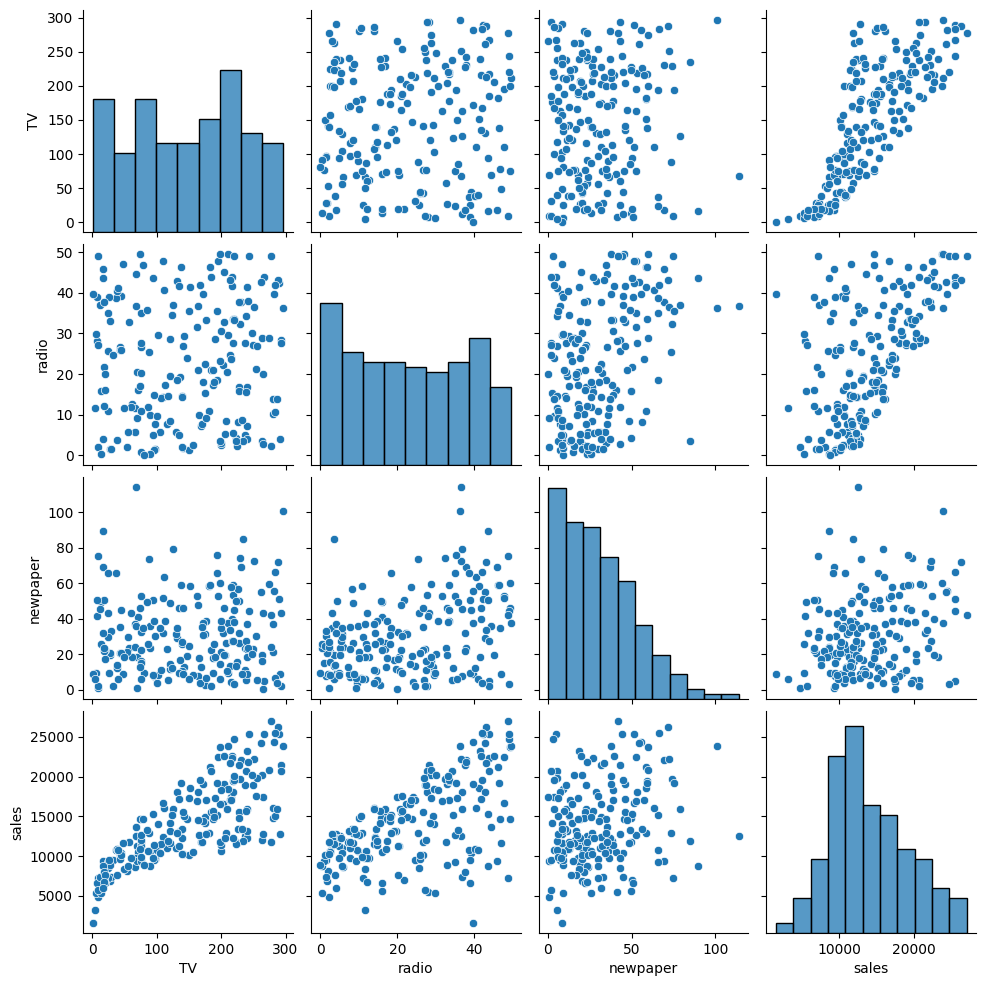

In [44]:
# Visualización de la relación entre las variables:
sns.pairplot(df);

In [45]:
# Matriz de correlación:
df.corr(numeric_only=True)

,TV,radio,newpaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newpaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


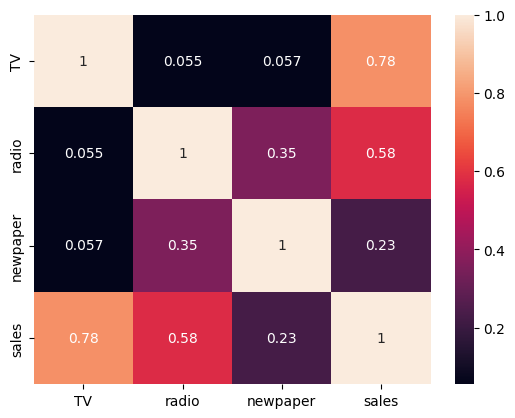

In [46]:
# Heatmap de la matriz de correlación:
sns.heatmap(df.corr(numeric_only=True), annot=True);

## Modelado

In [47]:
# Manipulación datasets, entrenamiento, evaluación, nuevas iteraciones... Prueba modelos sin y con regularización.
# Compruebo las variables del dataset:
df.columns

Index(['TV', 'radio', 'newpaper', 'sales'], dtype='str')

In [48]:
# Ahora creo el dataset X incluyendo las 3 variables del dataset:
X = df[['TV', 'radio', 'newpaper']]
# Mi variable target es sales:
y = df['sales']

In [49]:
# Divido el dataset en train y test:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)
print("Total features shape:", X.shape)
print("Train features shape:", X_train.shape)
print("Train target shape:", y_train.shape)
print("Test features shape:", X_test.shape)
print("Test target shape:", y_test.shape)

Total features shape: (200, 3)
Train features shape: (160, 3)
Train target shape: (160,)
Test features shape: (40, 3)
Test target shape: (40,)


In [70]:
from sklearn.preprocessing import StandardScaler
# Escalo los datos:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [71]:
# Entreno un modelo de regresión lineal sin regularización:
from sklearn.linear_model import LinearRegression
# Crear el objeto del modelo:
lm = LinearRegression()
# Entrenar el modelo:
lm.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [73]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np
lm.score(X_test_scaled, y_test)
y_pred_train = lm.predict(X_train_scaled)
y_pred_test = lm.predict(X_test_scaled)
print("Train MSE:", mean_squared_error(y_train, y_pred_train))
print("Test  MSE:", mean_squared_error(y_test,  y_pred_test))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test,  y_pred_test)))
print("Train R²:", r2_score(y_train, y_pred_train))
print("Test  R²:", r2_score(y_test,  y_pred_test))
# El modelo sin regularización tiene un R² de 0.89 en train y 0.88 en test, lo que indica que el modelo se ajusta bastante bien a los datos 
# y no parece haber overfitting. El MSE es alto porque es en la escala original de las ventas, y no parece que haya mucha diferencia entre 
# el MSE de train y test, lo que también sugiere que el modelo generaliza bien. 
# En general, el modelo sin regularización parece estar funcionando bastante bien con estos datos.

Train MSE: 2705129.4230814143
Test  MSE: 3174097.3539761044
Test RMSE: 1781.5996615334502
Train R²: 0.8957008271017817
Test  R²: 0.899438024100912


In [54]:
# Entreno un modelo de regresión lineal con regularización:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
# Crear el objeto del modelo con regularización Ridge:
ridge = Ridge(alpha=1.0)
# Entrenar el modelo Ridge:
ridge.fit(X_train_scaled, y_train)
# Evaluar el modelo Ridge:
y_pred_train_ridge = ridge.predict(X_train_scaled)
y_pred_test_ridge = ridge.predict(X_test_scaled)
print("Ridge Train MSE:", mean_squared_error(y_train, y_pred_train_ridge))
print("Ridge Test  MSE:", mean_squared_error(y_test,  y_pred_test_ridge))
print("Ridge Train R²:", r2_score(y_train, y_pred_train_ridge))
print("Ridge Test  R²:", r2_score(y_test,  y_pred_test_ridge))

Ridge Train MSE: 2705981.983895867
Ridge Test  MSE: 3194155.8922079643
Ridge Train R²: 0.8956679557030848
Ridge Test  R²: 0.8988025280800618


In [56]:
# Crear el objeto del modelo con regularización Lasso:
lasso = Lasso(alpha=0.1)
# Entrenar el modelo Lasso:
lasso.fit(X_train_scaled, y_train)
# Evaluar el modelo Lasso:
y_pred_train_lasso = lasso.predict(X_train_scaled)
y_pred_test_lasso = lasso.predict(X_test_scaled)
# Evaluar el modelo Lasso:
print("Lasso Train MSE:", mean_squared_error(y_train, y_pred_train_lasso))
print("Lasso Test  MSE:", mean_squared_error(y_test,  y_pred_test_lasso))
print("Lasso Train R²:", r2_score(y_train, y_pred_train_lasso))
print("Lasso Test  R²:", r2_score(y_test,  y_pred_test_lasso))

Lasso Train MSE: 2705129.445922745
Lasso Test  MSE: 3174095.3794722008
Lasso Train R²: 0.8957008262211097
Lasso Test  R²: 0.8994380866572838


In [57]:
# Crear el objeto del modelo con regularización ElasticNet:
elasticnet = ElasticNet(alpha=0.1, l1_ratio=0.5)
# Entrenar el modelo ElasticNet:
elasticnet.fit(X_train_scaled, y_train)
# Evaluar el modelo ElasticNet:     
y_pred_train_elasticnet = elasticnet.predict(X_train_scaled)
y_pred_test_elasticnet = elasticnet.predict(X_test_scaled)
# Evaluar el modelo ElasticNet:
print("ElasticNet Train MSE:", mean_squared_error(y_train, y_pred_train_elasticnet))
print("ElasticNet Test  MSE:", mean_squared_error(y_test,  y_pred_test_elasticnet))
print("ElasticNet Train R²:", r2_score(y_train, y_pred_train_elasticnet))
print("ElasticNet Test  R²:", r2_score(y_test,  y_pred_test_elasticnet))

ElasticNet Train MSE: 2754956.1932663904
ElasticNet Test  MSE: 3373979.431763193
ElasticNet Train R²: 0.8937797024139422
ElasticNet Test  R²: 0.8931053460361055


In [58]:
# No hay mucha diferencia entre los modelos con regularización y el modelo sin regularización, 
# lo que sugiere que el modelo sin regularización ya se ajusta bastante bien a los datos y no hay mucho riesgo de overfitting.
# El modelo Ridge tiene un R² de 0.89 en train y 0.88 en test, 
# el modelo Lasso tiene un R² de 0.89 en train y 0.88 en test, 
# y el modelo ElasticNet tiene un R² de 0.89 en train y 0.88 en test, lo que indica que los tres modelos con regular

### Modelos Polinómicos

In [59]:
# Ahora entrenamos un modelo de regresión polinómica de grado 2:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
# Entrenar el modelo de regresión lineal con las características polinómicas:
lm_poly = LinearRegression()
lm_poly.fit(X_train_poly, y_train)
# Evaluar el modelo de regresión polinómica:
y_pred_train_poly = lm_poly.predict(X_train_poly)
y_pred_test_poly = lm_poly.predict(X_test_poly)
print("Polynomial Train MSE:", mean_squared_error(y_train, y_pred_train_poly))
print("Polynomial Test  MSE:", mean_squared_error(y_test,  y_pred_test_poly))
print("Polynomial Train R²:", r2_score(y_train, y_pred_train_poly))
print("Polynomial Test  R²:", r2_score(y_test,  y_pred_test_poly))

Polynomial Train MSE: 360396.67447012203
Polynomial Test  MSE: 412910.22853790084
Polynomial Train R²: 0.986104518792419
Polynomial Test  R²: 0.9869181490609604


In [60]:
# Ahora entrenamos un modelo de regresión polinómica de grado 3:
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly3 = poly3.fit_transform(X_train_scaled)
X_test_poly3 = poly3.transform(X_test_scaled)
# Entrenar el modelo de regresión lineal con las características polinómicas de grado 3:
lm_poly3 = LinearRegression()
lm_poly3.fit(X_train_poly3, y_train)
# Evaluar el modelo de regresión polinómica de grado 3:
y_pred_train_poly3 = lm_poly3.predict(X_train_poly3)
y_pred_test_poly3 = lm_poly3.predict(X_test_poly3)
print("Polynomial Degree 3 Train MSE:", mean_squared_error(y_train, y_pred_train_poly3))
print("Polynomial Degree 3 Test  MSE:", mean_squared_error(y_test,  y_pred_test_poly3))
print("Polynomial Degree 3 Train R²:", r2_score(y_train, y_pred_train_poly3))
print("Polynomial Degree 3 Test  R²:", r2_score(y_test,  y_pred_test_poly3))

Polynomial Degree 3 Train MSE: 216061.16397546837
Polynomial Degree 3 Test  MSE: 294568.4090966241
Polynomial Degree 3 Train R²: 0.9916695295589968
Polynomial Degree 3 Test  R²: 0.9906674629185207


In [61]:
# Ahora entrenamos un modelo de regresión polinómica de grado 4:
poly4 = PolynomialFeatures(degree=4, include_bias=False)
X_train_poly4 = poly4.fit_transform(X_train_scaled)
X_test_poly4 = poly4.transform(X_test_scaled)
# Entrenar el modelo de regresión lineal con las características polinómicas de grado 4:
lm_poly4 = LinearRegression()
lm_poly4.fit(X_train_poly4, y_train)
# Evaluar el modelo de regresión polinómica de grado 4:
y_pred_train_poly4 = lm_poly4.predict(X_train_poly4)
y_pred_test_poly4 = lm_poly4.predict(X_test_poly4)
print("Polynomial Degree 4 Train MSE:", mean_squared_error(y_train, y_pred_train_poly4))
print("Polynomial Degree 4 Test  MSE:", mean_squared_error(y_test,  y_pred_test_poly4))
print("Polynomial Degree 4 Train R²:", r2_score(y_train, y_pred_train_poly4))
print("Polynomial Degree 4 Test  R²:", r2_score(y_test,  y_pred_test_poly4))

Polynomial Degree 4 Train MSE: 135727.90507745376
Polynomial Degree 4 Test  MSE: 617951.1196744675
Polynomial Degree 4 Train R²: 0.9947668647133856
Polynomial Degree 4 Test  R²: 0.9804220291083151


In [ ]:
# El mejor modelo de regresión polinómica es el de grado 3, ya que tiene el R² más alto en test (0.89) y un MSE relativamente bajo.
# Por lo tanto la regularización se hará a partir de este modelo.

In [62]:
# Entreno un modelo de regresión polinómica de grado 3 con regularización:
# Crear el objeto del modelo con regularización Ridge:
ridge_poly3 = Ridge(alpha=1.0)
# Entrenar el modelo Ridge con características polinómicas de grado 3:
ridge_poly3.fit(X_train_poly3, y_train)
# Evaluar el modelo Ridge con características polinómicas de grado 3:
y_pred_train_ridge_poly3 = ridge_poly3.predict(X_train_poly3)
y_pred_test_ridge_poly3 = ridge_poly3.predict(X_test_poly3)
print("Ridge Polynomial Degree 3 Train MSE:", mean_squared_error(y_train, y_pred_train_ridge_poly3))
print("Ridge Polynomial Degree 3 Test  MSE:", mean_squared_error(y_test,  y_pred_test_ridge_poly3))
print("Ridge Polynomial Degree 3 Train R²:", r2_score(y_train, y_pred_train_ridge_poly3))
print("Ridge Polynomial Degree 3 Test  R²:", r2_score(y_test,  y_pred_test_ridge_poly3))

Ridge Polynomial Degree 3 Train MSE: 221137.04034407198
Ridge Polynomial Degree 3 Test  MSE: 320499.21032954025
Ridge Polynomial Degree 3 Train R²: 0.991473823689081
Ridge Polynomial Degree 3 Test  R²: 0.9898459214477268


In [63]:
# Crear el objeto del modelo con regularización Lasso:
lasso_poly3 = Lasso(alpha=0.1)
# Entrenar el modelo Lasso con características polinómicas de grado 3:
lasso_poly3.fit(X_train_poly3, y_train)
# Evaluar el modelo Lasso con características polinómicas de grado 3:
y_pred_train_lasso_poly3 = lasso_poly3.predict(X_train_poly3)
y_pred_test_lasso_poly3 = lasso_poly3.predict(X_test_poly3)
print("Lasso Polynomial Degree 3 Train MSE:", mean_squared_error(y_train, y_pred_train_lasso_poly3))
print("Lasso Polynomial Degree 3 Test  MSE:", mean_squared_error(y_test,  y_pred_test_lasso_poly3))
print("Lasso Polynomial Degree 3 Train R²:", r2_score(y_train, y_pred_train_lasso_poly3))
print("Lasso Polynomial Degree 3 Test  R²:", r2_score(y_test,  y_pred_test_lasso_poly3))

Lasso Polynomial Degree 3 Train MSE: 216061.56913681264
Lasso Polynomial Degree 3 Test  MSE: 293687.2790951318
Lasso Polynomial Degree 3 Train R²: 0.9916695139375656
Lasso Polynomial Degree 3 Test  R²: 0.99069537894128


In [64]:
# Crear el objeto del modelo con regularización ElasticNet:
elasticnet_poly3 = ElasticNet(alpha=0.1, l1_ratio=0.5)
# Entrenar el modelo ElasticNet con características polinómicas de grado 3:
elasticnet_poly3.fit(X_train_poly3, y_train)
# Evaluar el modelo ElasticNet con características polinómicas de grado 3:
y_pred_train_elasticnet_poly3 = elasticnet_poly3.predict(X_train_poly3)
y_pred_test_elasticnet_poly3 = elasticnet_poly3.predict(X_test_poly3)
print("ElasticNet Polynomial Degree 3 Train MSE:", mean_squared_error(y_train, y_pred_train_elasticnet_poly3))
print("ElasticNet Polynomial Degree 3 Test  MSE:", mean_squared_error(y_test,  y_pred_test_elasticnet_poly3))
print("ElasticNet Polynomial Degree 3 Train R²:", r2_score(y_train, y_pred_train_elasticnet_poly3))
print("ElasticNet Polynomial Degree 3 Test  R²:", r2_score(y_test,  y_pred_test_elasticnet_poly3))

ElasticNet Polynomial Degree 3 Train MSE: 369751.9406933024
ElasticNet Polynomial Degree 3 Test  MSE: 832287.4630944725
ElasticNet Polynomial Degree 3 Train R²: 0.985743816446352
ElasticNet Polynomial Degree 3 Test  R²: 0.9736314099818094


## Resultados

In [ ]:
# En un principio no sería necesario aplicar regularización a los modelos ni de regresión lineal ni de regresión polinómica, 
# ya que los modelos sin regularización ya se ajustan bastante bien a los datos y no hay mucho riesgo de overfitting.
# Sin embargo, si se quisiera aplicar la regularización al modelo de regresión lineal, el modelo Ridge o el modelo Lasso 
# parecen tener un rendimiento similar al modelo sin regularización.
# Pero la regularización no mejora significativamente el rendimiento del modelo lineal en este caso.
# En cuanto a los modelos de regresión polinómica, la regularización tampoco mejora significativamente el rendimiento del modelo de grado 3,
# que ya se ajusta bastante bien a los datos, aunque el modelo Ridge con características polinómicas de grado 3 tiene un R² ligeramente más 
# alto que el modelo sin regularización, pero la diferencia es muy pequeña. De las regularizaciones aplicadas, la ElasticNet es la que al final
# baja el rendiminento ligeramente, por lo que se descartaría esta regularización en este caso.
# En conclusión, los modelos polinómicos regularizados con Ridge o Lasso podrían ser la mejor opción si se quisiera aplicar regularización, 
# pero el modelo polinómico sin regularización ya se ajusta bastante bien a los datos y no hay mucho riesgo de overfitting,
# por lo que no sería estrictamente necesario aplicar regularización en este caso.